In [28]:
from solver_selection_thm.physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt

In [29]:
from spe_runscript import make_solver_space_scheme_hm

solver_space = SolverSpace(
    solver_space_scheme=make_solver_space_scheme_hm(nd=3),
    solver_scheme_builders=KNOWN_SOLVER_COMPONENTS_THM,
)
num_solvers = len(solver_space.all_decisions_encoding)
print(solver_space.decision_tree)
print("Num solvers:", num_solvers)

performance_predictor = PerformancePredictorPassiveAgressive(
    num_solvers=num_solvers,
)
solver_selector = SolverSelector(
    reward_estimator=RewardEstimator(),
    solver_space=solver_space,
    performance_predictor=performance_predictor,
)

block_type: PetscKSPScheme
| ksp_gmres_restart: Choices from 10 to 50, len = 3
| block_type (fork with 1 branches):
| | block_type: PetscFieldSplitScheme
| | | elim_options (fork with 1 branches):
| | | | python_pc_type: hypre
| | | | | python_pc_hypre_boomeramg_strong_threshold: Choices from 0.5 to 0.9, len = 3
| | | | | python_pc_hypre_boomeramg_agg_nl: Choices from 0 to 2, len = 3
| | | | | python_pc_hypre_boomeramg_relax_type_all (fork with 1 branches):
| | | | | | symmetric-SOR/Jacobi
Num solvers: 27


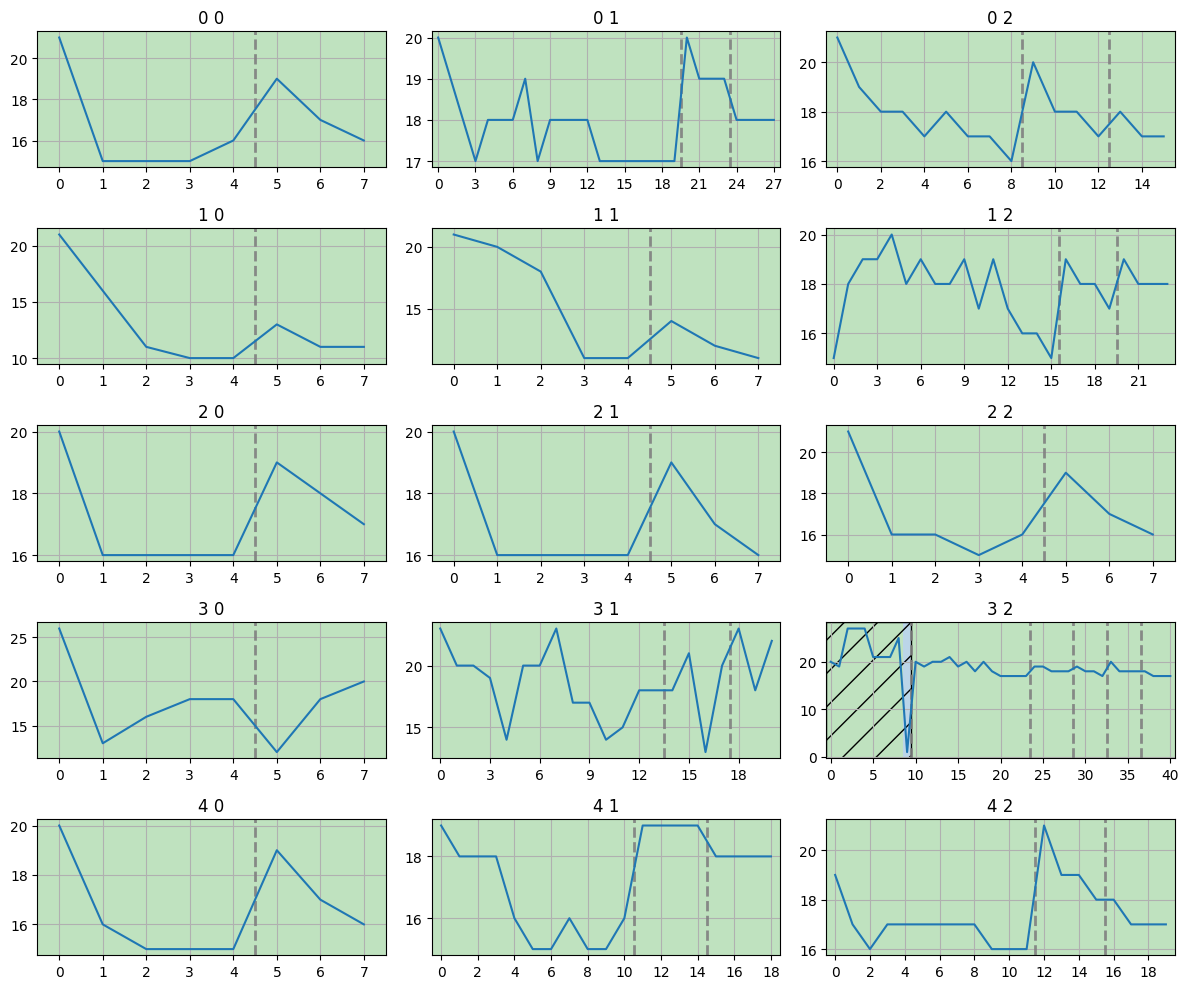

In [30]:
from itertools import count
from copy import copy
from plot_utils import (
    color_converged_reason,
    color_time_steps,
    get_gmres_iterations,
    load_data,
    get_cfl,
    get_enthalpy_max,
    get_peclet_max,
    get_temp_max,
    get_temp_min,
    get_num_sticking_sliding_open,
    get_linear_solve_time
)
from solver_selection_thm.spe_physics import X_SLICES, Z_SLICES, simulation_name, params


data_simulations = []
solver_selection_history = []

np.random.seed(42)
run_idx = 0
np.random.shuffle(Z_SLICES)
np.random.shuffle(X_SLICES)


for z_slice in Z_SLICES:
    data_row = []
    data_simulations.append(data_row)
    for x_slice in X_SLICES:
        params["x_slice"] = x_slice
        params["z_slice"] = z_slice
        sim_name = f"run_{run_idx}_{simulation_name(params)}"
        try:
            data = load_data(f"../stats/{sim_name}.json")
            solver_selector.history.load(f"../stats/solver_selection_history_{sim_name}.npy")
            solver_selection_history.append(copy(solver_selector.history))
            data_row.append(data)
        except FileNotFoundError:
            solver_selection_history.append(None)
            data_row.append(None)


fig, axes = plt.subplots(
    nrows=len(Z_SLICES), ncols=len(X_SLICES), figsize=(12, 10)
)
for i, data_row in enumerate(data_simulations):
    for j, data in enumerate(data_row):
        if data == None:
            continue
        ax = axes[i][j]
        plt.sca(ax)

        color_converged_reason(data)
        color_time_steps(data)

        ax.plot(get_gmres_iterations(data))
        # ax.set_yscale('log')
        # print(inlet_placement, outlet_placement)
        ax.set_title(f"{i} {j}")

plt.tight_layout()

(-2.0, 0.0)

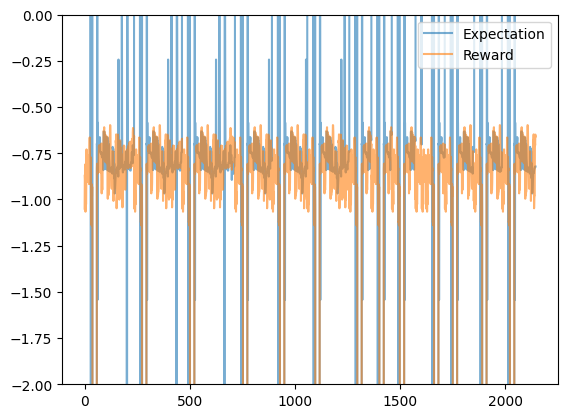

In [41]:
from solver_selection_thm.selector import SolverSelectorHistory
common_history = SolverSelectorHistory()
for x in solver_selection_history:
    common_history.features.extend(x.features)
    common_history.reward.extend(x.reward)
    common_history.decision_idx.extend(x.decision_idx)
    common_history.greedy.extend(x.greedy)   
    common_history.expectation.extend(x.expectation)

plt.plot(common_history.expectation, label='Expectation', alpha=0.6)
plt.plot(common_history.reward, label='Reward', alpha=0.6)
plt.legend()
plt.ylim(-2, 0)

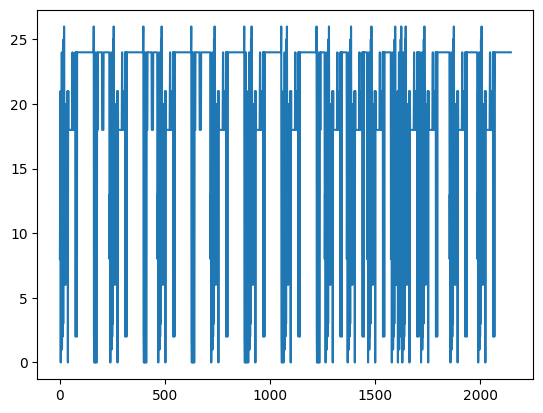

In [34]:
plt.plot(common_history.decision_idx)


In [44]:
decision_id = np.array(common_history.decision_idx)
X, y = np.array(common_history.features), np.array(common_history.reward)

# In offline setting, how well does the data describe the target?
1. Estimating Mutual Information (MI)


<BarContainer object of 16 artists>

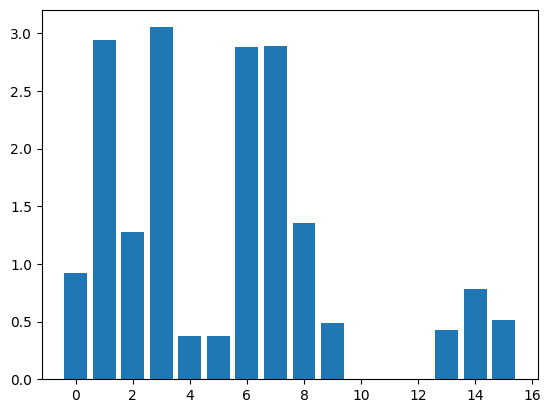

In [45]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

# compute MI
mi = mutual_info_regression(
    StandardScaler().fit_transform(X), y, n_neighbors=10, random_state=42
)
plt.bar(range(len(mi)), mi)

In [66]:
from sklearn.linear_model import PassiveAggressiveRegressor, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Only this model is used
def make_model():
        passive_agressive_regressor = SGDRegressor(
            penalty="l1",
            random_state=42,
            learning_rate="pa1",
            loss="epsilon_insensitive",
            epsilon=0.1,
        )
        transform_pipeline =StandardScaler()
        return transform_pipeline, passive_agressive_regressor

    # scaler = StandardScaler()
    # # scaler = StandardScaler(with_mean=False, with_std=False)
    # # regressor = PassiveAggressiveRegressor(random_state=42)
    # regressor = SGDRegressor(
    #     penalty="l2",
    #     random_state=42,
    #     # learning_rate="pa1",  # better without
    #     # loss="epsilon_insensitive",
    #     epsilon=0.1,
    # )
    # # regressor = KNeighborsRegressor(n_neighbors=10)
    # return scaler, regressor

2. Training offline model with cross-validation and comparing its

In [67]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

offline_pipeline = make_pipeline(*make_model()) 
cv_results = cross_validate(offline_pipeline, X, y, cv=6, scoring="r2", return_train_score=True, return_estimator=True)

# Output
print("Train R² scores:", cv_results["train_score"])
print("Test R² scores:", cv_results["test_score"])
print("Mean Train R²:", np.mean(cv_results["train_score"]))
print("Mean Test R²:", np.mean(cv_results["test_score"]))

best_regressor_offline = cv_results['estimator'][np.argmax(cv_results['test_score'])]
best_regressor_offline

Train R² scores: [0.99688183 0.99767344 0.99744898 0.99659044 0.99616505 0.99818605]
Test R² scores: [0.99675309 0.99380163 0.99704643 0.99735992 0.99692627 0.99784692]
Mean Train R²: 0.9971576314020495
Mean Test R²: 0.9966223762301484


,steps,"[('standardscaler', ...), ('sgdregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'epsilon_insensitive'
,penalty,'l1'
,alpha,0.0001
,l1_ratio,0.15


3. We split data into offline and online. Online data is to be used for cross-validation split to train and test.

In [68]:
sep = num_solvers
Xoffline, yoffline = X[:sep], y[:sep]
Xonline, yonline = X[sep:], y[sep:]

3. Cross-validation R2 score of the online model

In [69]:
from sklearn.base import BaseEstimator, RegressorMixin
import math


class OnlineRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, Xoffline, yoffline):
        self.Xoffline = Xoffline
        self.yoffline = yoffline
        self.scaler, self.regressor = make_model()
        self.scaler.fit(Xoffline)
        self.regressor.fit(self.scaler.transform(Xoffline), yoffline)
        self.window_size = 1

    def fit(self, X, y):
        for i in range(math.ceil(X.shape[0] / self.window_size)):
            start = i * self.window_size
            end = start + self.window_size
            Xbatch, ybatch = X[start:end], y[start:end]
            self.scaler.partial_fit(Xbatch)
            self.regressor.partial_fit(self.scaler.transform(Xbatch), ybatch)

    def predict(self, X):
        return self.regressor.predict(self.scaler.transform(X))

    

online_regressor = OnlineRegressor(Xoffline, yoffline)
cv_results_online = cross_validate(online_regressor, Xonline, yonline, cv=6, scoring="r2", return_train_score=True, return_estimator=True)

# Output
print("Train R² scores:", cv_results_online["train_score"])
print("Test R² scores:", cv_results_online["test_score"])
print("Mean Train R²:", np.mean(cv_results_online["train_score"]))
print("Mean Test R²:", np.mean(cv_results_online["test_score"]))

best_regressor_online = cv_results_online['estimator'][np.argmax(cv_results_online['test_score'])]
best_regressor_online

Train R² scores: [0.99620427 0.99648342 0.99611082 0.99561986 0.9952478  0.99736607]
Test R² scores: [0.99564772 0.99305886 0.99553877 0.99696678 0.99674186 0.99696967]
Mean Train R²: 0.9961720391534515
Mean Test R²: 0.9958206107620459


,Xoffline,array([[8.640...0000000e-01]])
,yoffline,array([-1.049... -0.86432141])


4. Now we treat them as classifiers. Offline - ground truth. How often does Online make different decisions? How much does this cost to it?

In [70]:
from sklearn.neighbors import KNeighborsRegressor

def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)


best_regressor_offline = KNeighborsRegressor(n_neighbors=20)
best_regressor_offline.fit(X, y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding
Xonline_features.shape

scaler_online, regressor_online = make_model()
scaler_online.fit(Xoffline)
regressor_online.fit(scaler_online.transform(Xoffline), yoffline)

decisions_online = []
decisions_offline = []
reward_offline = []
reward_online = []
reward_feedback = []

for Xfeature in Xonline_features:
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # online
    predictions_online = regressor_online.predict(scaler_online.transform(x_to_predict))
    max_score_idx_online = np.argmax(predictions_online)
    max_score_online = predictions_online[max_score_idx_online]

    # offline
    predictions_offline = best_regressor_offline.predict(x_to_predict)
    max_score_idx_offline = np.argmax(predictions_offline)
    max_score_offline = predictions_offline[max_score_idx_offline]

    # feedback
    X_feedback = x_to_predict[max_score_idx_online].reshape(1, -1)
    y_feedback = predictions_offline[max_score_idx_online]
    scaler_online.partial_fit(X_feedback, [y_feedback])
    regressor_online.partial_fit(scaler_online.transform(X_feedback), [y_feedback])

    # saving stats
    decisions_offline.append(max_score_idx_offline)
    decisions_online.append(max_score_idx_online)
    reward_feedback.append(y_feedback)
    reward_offline.append(max_score_offline)
    reward_online.append(max_score_online)

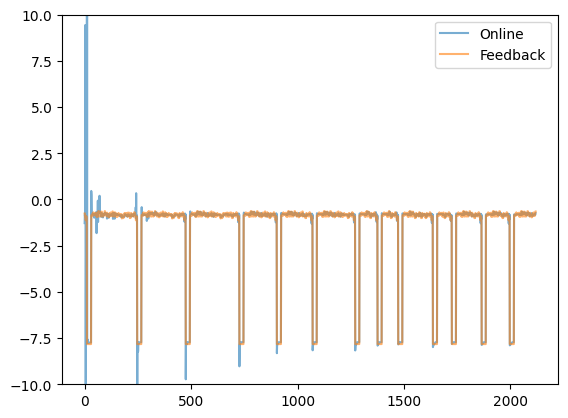

In [71]:
plt.plot(reward_online, label='Online', alpha=0.6)
plt.plot(reward_feedback, label='Feedback', alpha=0.6)
plt.ylim(-10, 10)
plt.legend()

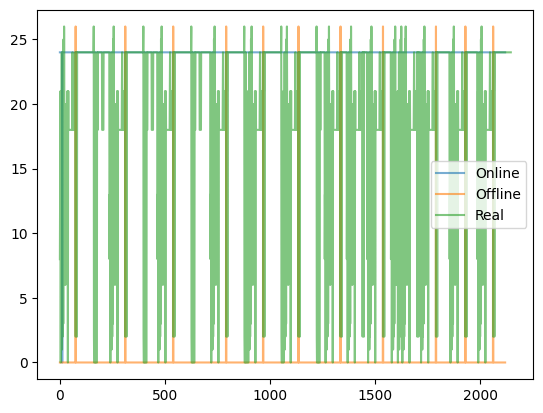

In [72]:
plt.plot(decisions_online, label='Online', alpha=0.6)
plt.plot(decisions_offline, label='Offline', alpha=0.6)
plt.plot(common_history.decision_idx, label='Real', alpha=0.6)
plt.legend()

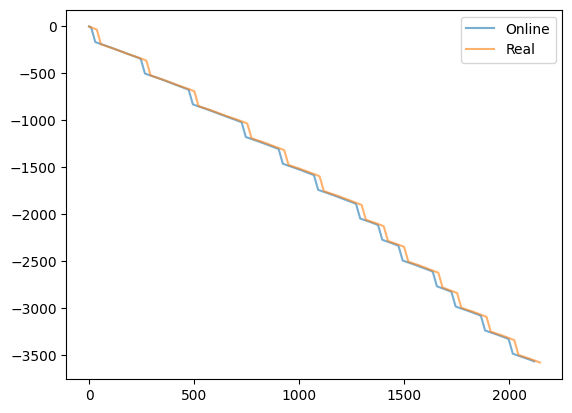

In [ ]:
plt.plot(np.cumsum(reward_feedback), label='Online', alpha=0.6)
plt.plot(np.cumsum(reward_offline), label='Offline', alpha=0.6)
plt.plot(np.cumsum(common_history.reward), label='Real', alpha=0.6)
plt.legend()